# Data audit / EDA

Roadmap stage 3. This notebook is self-contained: it downloads the
dataset itself (same as `01_dataset_download_colab.ipynb`), so it can be
run on its own in a fresh Colab session without depending on another
notebook having run first.

## Step 3.1 — Verify dataset integrity

Goal: confirm all 200 class folders are present, and that every image file
actually opens correctly (not just a sample — with ~116K files this is
fast enough to check all of them and get a definitive answer).

### Setup: download the dataset (from Google Drive, authenticated)

Uses Colab's built-in Google auth + the Drive API to download by file ID,
as the file's own owner — not the public "anyone with the link" path.
This avoids Google Drive's anti-abuse download quota on shared links
(which we hit during testing: "Too many users have viewed or downloaded
this file recently"). You'll get a one-time login/consent popup.

In [ ]:
from google.colab import auth
auth.authenticate_user()

import io
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

FILE_ID = "1Mi0IleRucNmwnQ4g_ZEWOyBFFv4mO9ba"
ZIP_PATH = "/content/traffic_sign_dataset.zip"

drive_service = build('drive', 'v3')
request = drive_service.files().get_media(fileId=FILE_ID)

with io.FileIO(ZIP_PATH, 'wb') as fh:
    downloader = MediaIoBaseDownload(fh, request, chunksize=200 * 1024 * 1024)
    done = False
    while not done:
        status, done = downloader.next_chunk()
        print(f"Download progress: {int(status.progress() * 100)}%")

print("Download complete.")

In [ ]:
import os

EXPECTED_SIZE = 14_945_416_206  # bytes, from the local audit

assert os.path.exists(ZIP_PATH), (
    "Download failed: no file was written at all. Check the gdown output above for errors."
)
actual_size = os.path.getsize(ZIP_PATH)
print(f"Downloaded file size: {actual_size:,} bytes ({actual_size / 1e9:.2f} GB)")
print(f"Expected size: {EXPECTED_SIZE:,} bytes ({EXPECTED_SIZE / 1e9:.2f} GB)")

assert actual_size > 1_000_000_000, (
    "Downloaded file is far too small to be the real dataset (likely Google Drive's "
    "'can't scan this file for viruses' warning page instead of the actual zip). "
    "Check that the Drive file's sharing is set to 'Anyone with the link', then re-run "
    "the download cell above."
)
print("Size check passed — looks like the real file.")

In [ ]:
!rm -rf /content/dataset
!mkdir -p /content/dataset
!unzip -q "$ZIP_PATH" -d /content/dataset
!rm "$ZIP_PATH"

from pathlib import Path
data_path = Path('/content/dataset/Data')
assert data_path.is_dir(), (
    "Unzip did not produce /content/dataset/Data as expected — the zip may be "
    "corrupt or incomplete. Re-run the download cell and check its output for errors."
)
n_classes = len(list(data_path.iterdir()))
print(f"Unzip done, zip file removed. Found {n_classes} folders under Data/.")

**Note on saved outputs**: the setup cells above (Colab Drive download + unzip) were not re-run for this committed version -- they need Colab. Everything from here down *was* actually run and shows real, current output: captured locally against an extracted copy of the identical dataset zip (same 116,642 files Colab would download), via scripts/capture_local_notebook_outputs.py, since these results only depend on the dataset's contents, not on which environment reads them. Re-running the cells above in Colab would reproduce the same numbers.

### 3.1a — Confirm all 200 class folders are present

In [1]:
from pathlib import Path

data_dir = Path('/content/dataset/Data')
class_folders = sorted(data_dir.iterdir(), key=lambda p: int(p.name))

found = set(p.name for p in class_folders)
expected = set(str(i) for i in range(200))

print(f"Found {len(class_folders)} class folders")
print("Missing classes:", sorted(expected - found, key=int) or "None")
print("Unexpected extra folders:", sorted(found - expected) or "None")

Found 200 class folders
Missing classes: None
Unexpected extra folders: None


### 3.1b — Verify every image actually opens (full check, not a sample)

In [2]:
from PIL import Image
from tqdm import tqdm

corrupt_files = []
total_checked = 0

for class_folder in tqdm(class_folders, desc="Checking classes"):
    for img_path in class_folder.iterdir():
        total_checked += 1
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupt_files.append((str(img_path), str(e)))

print(f"\nChecked {total_checked} images")
print(f"Corrupt/unreadable: {len(corrupt_files)}")
for path, err in corrupt_files[:20]:
    print(" ", path, "->", err)


Checked 116642 images
Corrupt/unreadable: 0


### Result

If class folders = 200 with none missing, and corrupt/unreadable = 0 (or a
short, specific list), step 3.1 is done. Any corrupt files found here get
excluded before training later. Next: step 3.2, class distribution.

## Step 3.2 — Class distribution

Goal: quantify how many images each of the 200 classes has, and confirm
the imbalance already spotted locally (248 to 1,845 images per class).

In [3]:
import numpy as np

class_counts = {cf.name: len(list(cf.iterdir())) for cf in class_folders}
counts = np.array(list(class_counts.values()))

min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)

print(f"Number of classes: {len(counts)}")
print(f"Total images: {counts.sum()}")
print(f"Min images in a class: {counts.min()} (class {min_class})")
print(f"Max images in a class: {counts.max()} (class {max_class})")
print(f"Mean: {counts.mean():.1f}, Median: {np.median(counts):.1f}")
print(f"Imbalance ratio (max/min): {counts.max() / counts.min():.2f}x")

Number of classes: 200
Total images: 116642
Min images in a class: 248 (class 127)
Max images in a class: 1845 (class 0)
Mean: 583.2, Median: 483.5
Imbalance ratio (max/min): 7.44x


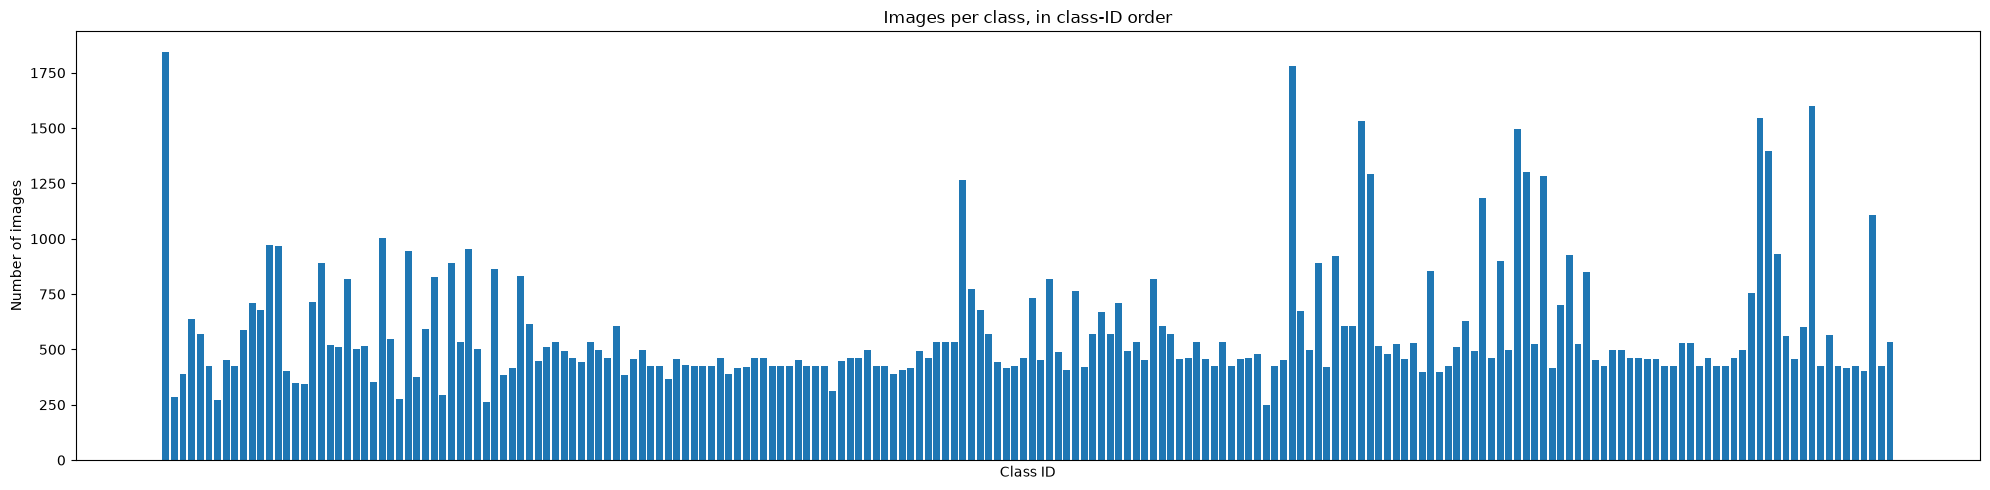

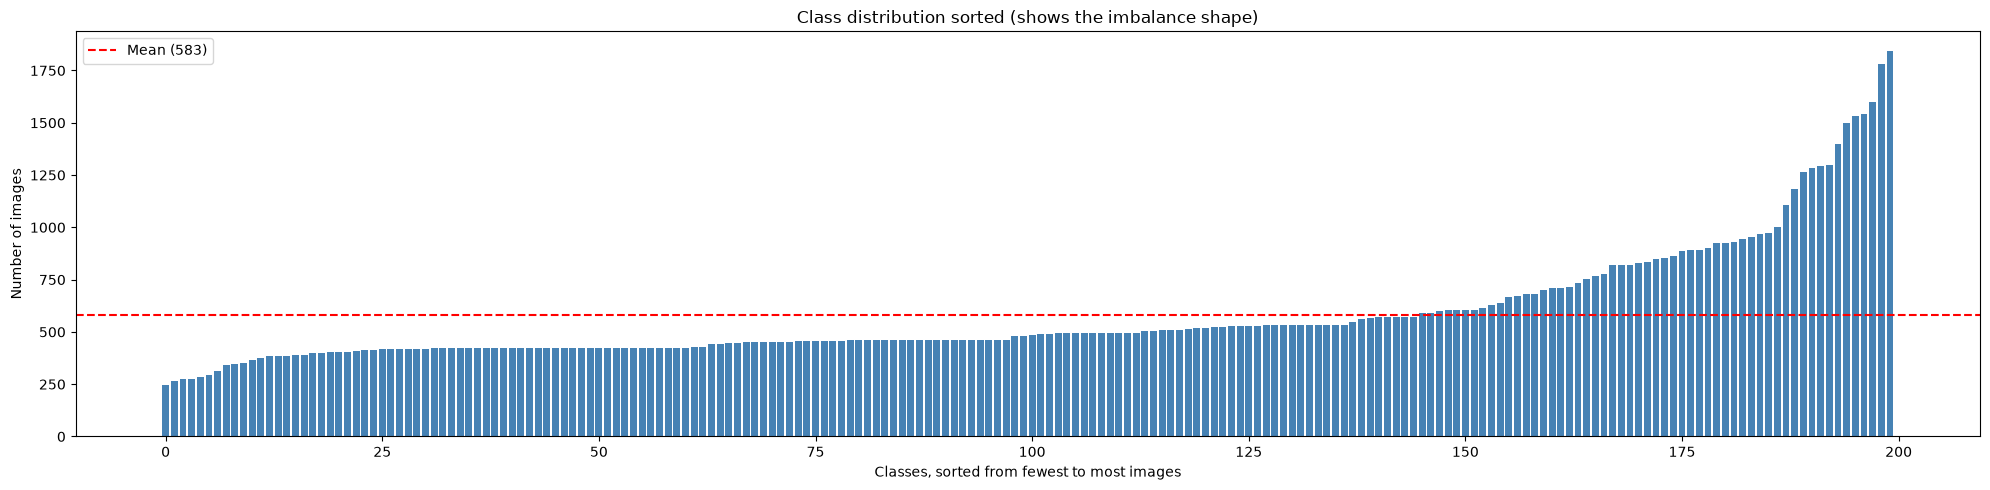

In [4]:
import matplotlib.pyplot as plt

# Bar chart in class-ID order
sorted_by_id = sorted(class_counts.items(), key=lambda x: int(x[0]))
plt.figure(figsize=(20, 5))
plt.bar([x[0] for x in sorted_by_id], [x[1] for x in sorted_by_id])
plt.xlabel('Class ID')
plt.ylabel('Number of images')
plt.title('Images per class, in class-ID order')
plt.xticks([])
plt.tight_layout()
plt.show()

# Same data sorted by count, so the imbalance is easy to see as a shape
sorted_by_count = sorted(class_counts.items(), key=lambda x: x[1])
plt.figure(figsize=(20, 5))
plt.bar(range(len(sorted_by_count)), [x[1] for x in sorted_by_count], color='steelblue')
plt.axhline(counts.mean(), color='red', linestyle='--', label=f'Mean ({counts.mean():.0f})')
plt.xlabel('Classes, sorted from fewest to most images')
plt.ylabel('Number of images')
plt.title('Class distribution sorted (shows the imbalance shape)')
plt.legend()
plt.tight_layout()
plt.show()

### Result

This confirms (or corrects) the imbalance we spotted earlier. The sorted
chart's shape matters more than exact numbers here: a gentle slope means
mild imbalance, a steep drop-off for a handful of classes means a few
classes are seriously underrepresented and will need special handling
(class weighting and/or extra augmentation) before training. Next: step
3.3, image properties (size, aspect ratio, color mode).

## Step 3.3 — Image property audit

Goal: check resolution range, aspect ratios, color mode, and file size
across the dataset. This tells us how to resize/normalize images
consistently before training.

In [5]:
import pandas as pd

records = []
for class_folder in tqdm(class_folders, desc="Reading image properties"):
    class_id = class_folder.name
    for img_path in class_folder.iterdir():
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
        file_size = img_path.stat().st_size
        records.append({
            'class_id': class_id,
            'width': width,
            'height': height,
            'mode': mode,
            'file_size_bytes': file_size,
        })

props_df = pd.DataFrame(records)
props_df['aspect_ratio'] = props_df['width'] / props_df['height']
print(f"Total images analyzed: {len(props_df)}")
props_df.head()

Total images analyzed: 116642


  class_id  width  height mode  file_size_bytes  aspect_ratio
0        0     47      48  RGB             5667      0.979167
1        0     50      48  RGB             5987      1.041667
2        0     53      51  RGB             6714      1.039216
3        0     57      54  RGB             7735      1.055556
4        0     59      58  RGB             8437      1.017241

In [6]:
print("--- Width (px) ---")
print(props_df['width'].describe())
print("\n--- Height (px) ---")
print(props_df['height'].describe())
print("\n--- Aspect ratio (width / height) ---")
print(props_df['aspect_ratio'].describe())
print("\n--- File size (bytes) ---")
print(props_df['file_size_bytes'].describe())
print("\n--- Color mode counts ---")
print(props_df['mode'].value_counts())

--- Width (px) ---
count    116642.000000
mean        260.493159
std         225.471253
min          25.000000
25%         103.000000
50%         191.000000
75%         340.000000
max        2749.000000
Name: width, dtype: float64

--- Height (px) ---
count    116642.000000
mean        225.662369
std         197.930328
min          25.000000
25%          91.000000
50%         157.000000
75%         295.000000
max        1496.000000
Name: height, dtype: float64

--- Aspect ratio (width / height) ---
count    116642.000000
mean          1.233785
std           0.567719
min           0.392857
25%           0.944444
50%           1.064516
75%           1.285714
max           5.883721
Name: aspect_ratio, dtype: float64

--- File size (bytes) ---
count    1.166420e+05
mean     1.279867e+05
std      2.518706e+05
min      8.530000e+02
25%      1.511400e+04
50%      4.466700e+04
75%      1.274870e+05
max      7.145146e+06
Name: file_size_bytes, dtype: float64

--- Color mode counts ---
mode
RGBA

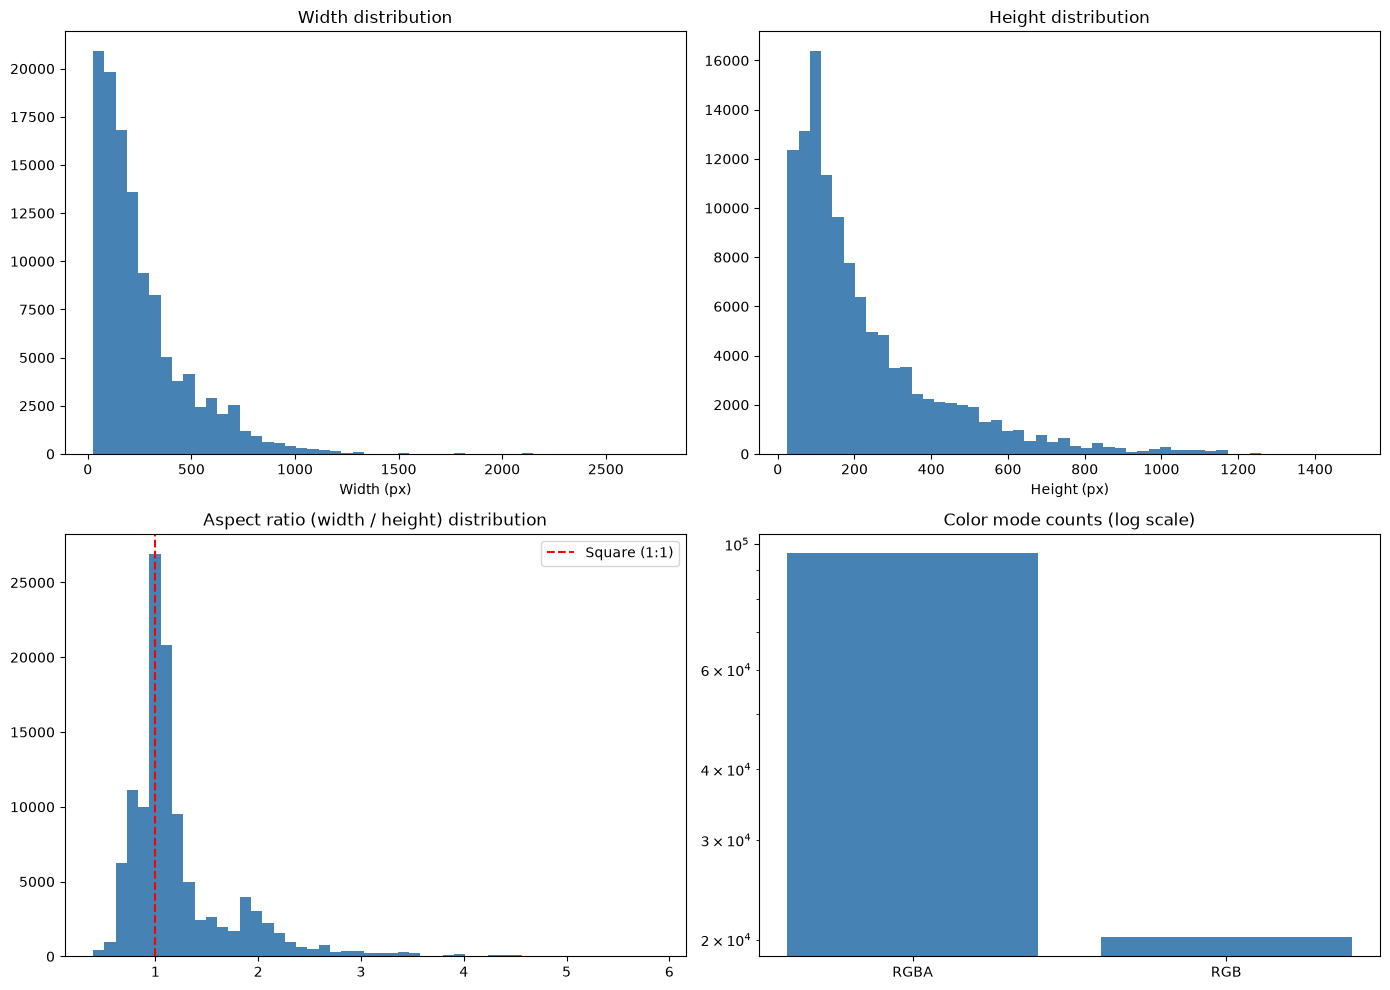

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(props_df['width'], bins=50, color='steelblue')
axes[0, 0].set_title('Width distribution')
axes[0, 0].set_xlabel('Width (px)')

axes[0, 1].hist(props_df['height'], bins=50, color='steelblue')
axes[0, 1].set_title('Height distribution')
axes[0, 1].set_xlabel('Height (px)')

axes[1, 0].hist(props_df['aspect_ratio'], bins=50, color='steelblue')
axes[1, 0].set_title('Aspect ratio (width / height) distribution')
axes[1, 0].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
axes[1, 0].legend()

mode_counts = props_df['mode'].value_counts()
axes[1, 1].bar(mode_counts.index.astype(str), mode_counts.values, color='steelblue')
axes[1, 1].set_title('Color mode counts (log scale)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

### Result

Key decisions this feeds into stage 4 (preprocessing):
- **Target resize size**: pick a fixed size (commonly small, e.g. 32x32 or
  64x64 for sign-classification CNNs) based on the resolution range above —
  no point training at a resolution higher than what most source images
  actually have.
- **Aspect ratio**: if most images are close to square (ratio near 1.0),
  resizing to a square target won't distort signs much. If there's a wide
  spread, we may want padding instead of a plain stretch-resize.
- **Color mode**: if it's overwhelmingly RGB with only a few exceptions,
  we'll just convert those exceptions to RGB rather than redesigning the
  pipeline around them.

Next: step 3.4, visual sample audit (actually look at example images).

## Step 3.4 — Visual sample audit

Goal: actually look at example images from a handful of classes — the
cheapest possible sanity check that a folder's images genuinely match one
consistent sign, not a labeling mistake. Class names aren't mapped yet
(that's step 3.5), so classes are shown by ID for now.

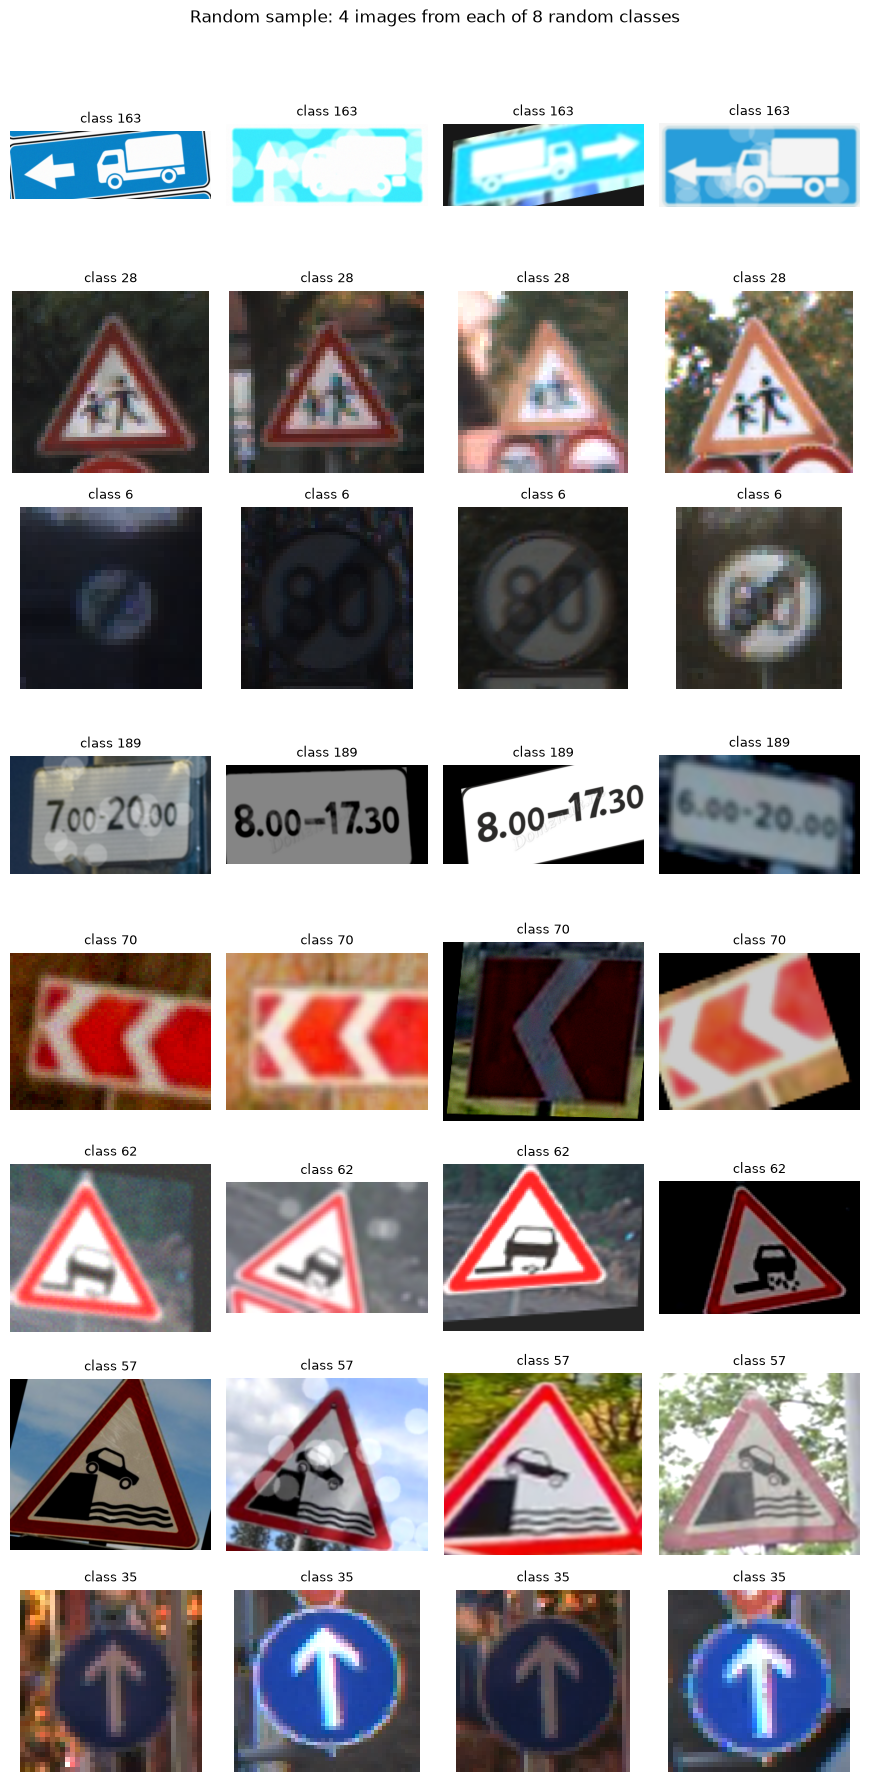

In [8]:
import random

random.seed(42)  # reproducible sample, same images every run

n_sample_classes = 8
images_per_class = 4

sample_class_ids = random.sample([cf.name for cf in class_folders], n_sample_classes)

fig, axes = plt.subplots(
    n_sample_classes, images_per_class,
    figsize=(images_per_class * 2.2, n_sample_classes * 2.2)
)

for row, class_id in enumerate(sample_class_ids):
    class_path = data_dir / class_id
    img_files = list(class_path.iterdir())
    chosen = random.sample(img_files, min(images_per_class, len(img_files)))
    for col in range(images_per_class):
        ax = axes[row, col]
        if col < len(chosen):
            with Image.open(chosen[col]) as img:
                ax.imshow(img.convert('RGB'))
            ax.set_title(f"class {class_id}", fontsize=9)
        ax.axis('off')

plt.suptitle('Random sample: 4 images from each of 8 random classes', y=1.01)
plt.tight_layout()
plt.show()

### Result

Check each row: do all 4 images in a row genuinely look like the *same*
sign (just different angle/lighting/distance), and does it look like a
real, distinct traffic sign (not a blank, a mistake, or an unrelated
photo)? If something looks wrong, note the class ID and we'll dig into
that specific folder. If it all looks consistent, step 3.4 is done. Next:
step 3.5, mapping class IDs to human-readable names.

## Step 3.5 — Class ID to human-readable name mapping

Goal: use the `Classes/` folder (which groups signs by category with real
names, e.g. `Classes/1 Priority/14 Stop/`) to map each numeric class ID to
a readable name, so later predictions can say "Stop sign" instead of
"class 14".

In [9]:
import re

classes_dir = Path('/content/dataset/Classes')
class_entries = {}

for category_dir in classes_dir.iterdir():
    if not category_dir.is_dir():
        continue
    for subfolder in category_dir.iterdir():
        if not subfolder.is_dir():
            continue
        m = re.match(r'^(\d+)\s+(.*)$', subfolder.name)
        if not m:
            continue  # unnumbered reference-only folders, not a Data/ class
        cid = int(m.group(1))
        name = m.group(2).strip()
        if cid == 81:
            # Known data quirk: two folders both claim ID 81
            # ("Height limit - 3.5" and "Height limit - 4.5"). Flag rather
            # than silently pick one.
            if cid in class_entries:
                class_entries[cid] = {
                    'name': 'Height limit (3.5 or 4.5, ambiguous in source data)',
                    'category': category_dir.name,
                }
            else:
                class_entries[cid] = {'name': name, 'category': category_dir.name}
        else:
            class_entries[cid] = {'name': name, 'category': category_dir.name}

print(f"Found {len(class_entries)} numbered class name entries")
missing = set(range(200)) - set(class_entries.keys())
print("Missing IDs (0-199) with no name found:", sorted(missing) or "None")

class_names_df = pd.DataFrame([
    {'class_id': cid, **class_entries[cid]} for cid in range(200)
]).sort_values('class_id').reset_index(drop=True)
class_names_df.head(10)

Found 200 numbered class name entries
Missing IDs (0-199) with no name found: None


   class_id                           name               category
0         0            Maximum speed limit          3 Prohibitory
1         1  Exit to a one-way road - left  5 Special regulations
2         2                     Speed bump  5 Special regulations
3         3       The tow truck is working           8 Additional
4         4             Photovideofixation           8 Additional
5         5        Except for the disabled           8 Additional
6         6     End of maximum speed limit          3 Prohibitory
7         7                Disabled people           8 Additional
8         8                    Wet coating           8 Additional
9         9                  No overtaking          3 Prohibitory

In [10]:
# Sanity check against the classes we actually have images for (from 3.1a)
data_class_ids = set(int(cf.name) for cf in class_folders)
mapped_ids = set(class_names_df['class_id'])

print("Classes with images but no name mapping:", sorted(data_class_ids - mapped_ids) or "None")
print("Classes with a name mapping but no image folder:", sorted(mapped_ids - data_class_ids) or "None")

# A few examples to eyeball against what we saw in the 3.4 visual sample
for cid in [0, 6, 14, 28, 81, 163, 189]:
    row = class_names_df[class_names_df['class_id'] == cid].iloc[0]
    print(f"class {cid}: {row['name']} ({row['category']})")

Classes with images but no name mapping: None
Classes with a name mapping but no image folder: None
class 0: Maximum speed limit (3 Prohibitory)
class 6: End of maximum speed limit (3 Prohibitory)
class 14: Stop (1 Priority)
class 28: Children (2 Warning)
class 81: Height limit (3.5 or 4.5, ambiguous in source data) (3 Prohibitory)
class 163: Truck route (6 Information)
class 189: Validity period (8 Additional)


### Result

All 200 classes should have exactly one name each, matching the 200
classes with images. One known data quirk: class 81 has two conflicting
names in the source taxonomy ("Height limit - 3.5" vs "Height limit -
4.5") — flagged rather than silently guessing which is correct.

The authoritative copy of this mapping is committed to the repo at
`metadata/class_names.csv` (derived directly from the dataset zip, not
retyped by hand, to avoid transcription errors across 200 rows).

Next: step 3.6, investigating whether the track/frame-numbered filenames
are near-duplicate frames of the same physical sign (the data-leakage
question).

## Step 3.6 — Investigate the track/frame-numbered filenames (leakage risk)

Some filenames look like `00000_00000_00017.png` — three numbers.
Hypothesis: group 1 = class ID, group 2 = a "track" ID (one specific
physical sign encountered while driving), group 3 = a frame number within
that track (consecutive video-like frames of the *same* sign as the
vehicle approaches it). If true, images in the same (class, track) group
are near-duplicates — splitting them across train/val/test would leak
near-identical images across the split and inflate test accuracy
artificially.

Not all files follow that exact pattern, though — this dataset looks like
it was merged from several original sources, each with its own naming
convention. We check all of them below rather than assuming one pattern
covers everything.

In [11]:
import re
from collections import Counter, defaultdict

# Several naming conventions coexist in this dataset (it looks merged from
# multiple original sources). Check each rather than assuming one pattern.
pat_a = re.compile(r'^(\d{5})_(\d{5})_(\d{5})\.\w+$', re.IGNORECASE)  # prefix_track_frame
pat_b = re.compile(r'^(\d{3})_(\d{4})\.\w+$', re.IGNORECASE)          # xxx_xxxx
pat_c = re.compile(r'^(\d{5})\.\w+$', re.IGNORECASE)                  # bare number, no track info

pattern_counts = Counter()
groups_a = defaultdict(list)  # (class_id, track_id) -> [frame_id, path]
mismatches_a = 0
other_examples = []

for class_folder in tqdm(class_folders, desc="Classifying filenames"):
    class_id = class_folder.name
    for img_path in class_folder.iterdir():
        name = img_path.name
        ma = pat_a.match(name)
        if ma:
            pattern_counts['A: prefix_track_frame'] += 1
            prefix, track, frame = ma.groups()
            groups_a[(class_id, track)].append((int(frame), img_path))
            if int(prefix) != int(class_id):
                mismatches_a += 1
            continue
        mb = pat_b.match(name)
        if mb:
            pattern_counts['B: xxx_xxxx'] += 1
            continue
        mc = pat_c.match(name)
        if mc:
            pattern_counts['C: bare number (no track info)'] += 1
            continue
        pattern_counts['D: other/unrecognized'] += 1
        if len(other_examples) < 8:
            other_examples.append(name)

total = sum(pattern_counts.values())
print("Filename pattern breakdown:")
for k, v in pattern_counts.items():
    print(f"  {k}: {v} ({v / total * 100:.1f}%)")

print(f"\nPattern A: class-folder mismatches with embedded prefix: {mismatches_a} "
      f"/ {pattern_counts['A: prefix_track_frame']}")
print("\nExamples of pattern D (other/unrecognized):")
for e in other_examples:
    print(" ", e)

Filename pattern breakdown:
  A: prefix_track_frame: 12053 (10.3%)
  C: bare number (no track info): 7655 (6.6%)
  B: xxx_xxxx: 224 (0.2%)
  D: other/unrecognized: 96710 (82.9%)

Pattern A: class-folder mismatches with embedded prefix: 802 / 12053

Examples of pattern D (other/unrecognized):
  000_0008_j.png
  000_1_0001.png
  000_1_0002.png
  000_1_0003.png
  000_1_0004.png
  000_1_0005.png
  000_1_0006.png
  000_1_0007.png


Pattern-A (class, track) groups: 900
Images per group -- min: 1, max: 60, mean: 13.39, median: 10
Groups with only 1 image: 11 (1.2%)
Groups with 5+ images: 734 (81.6%)


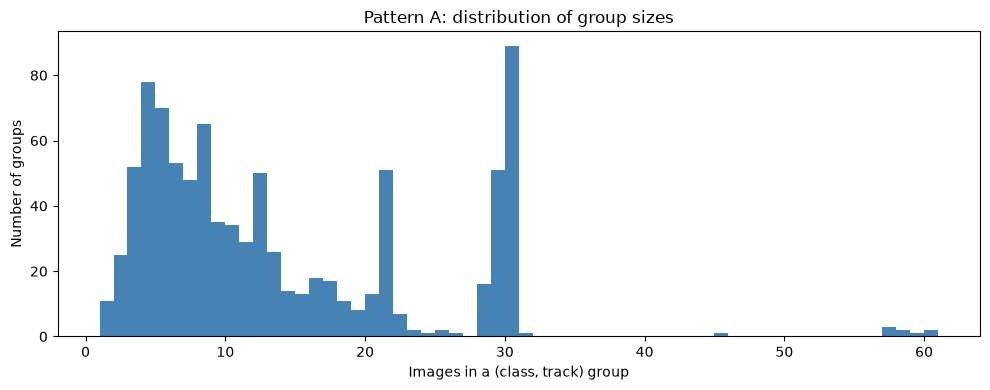

In [12]:
# Group sizes for pattern A specifically (the one with clean track/frame info)
track_sizes = {k: len(v) for k, v in groups_a.items()}
sizes = sorted(track_sizes.values())
n = len(sizes)

print(f"Pattern-A (class, track) groups: {n}")
print(f"Images per group — min: {sizes[0]}, max: {sizes[-1]}, "
      f"mean: {sum(sizes)/n:.2f}, median: {sizes[n // 2]}")
single = sum(1 for s in sizes if s == 1)
five_plus = sum(1 for s in sizes if s >= 5)
print(f"Groups with only 1 image: {single} ({single / n * 100:.1f}%)")
print(f"Groups with 5+ images: {five_plus} ({five_plus / n * 100:.1f}%)")

plt.figure(figsize=(10, 4))
plt.hist(sizes, bins=range(1, sizes[-1] + 2), color='steelblue')
plt.xlabel('Images in a (class, track) group')
plt.ylabel('Number of groups')
plt.title('Pattern A: distribution of group sizes')
plt.tight_layout()
plt.show()

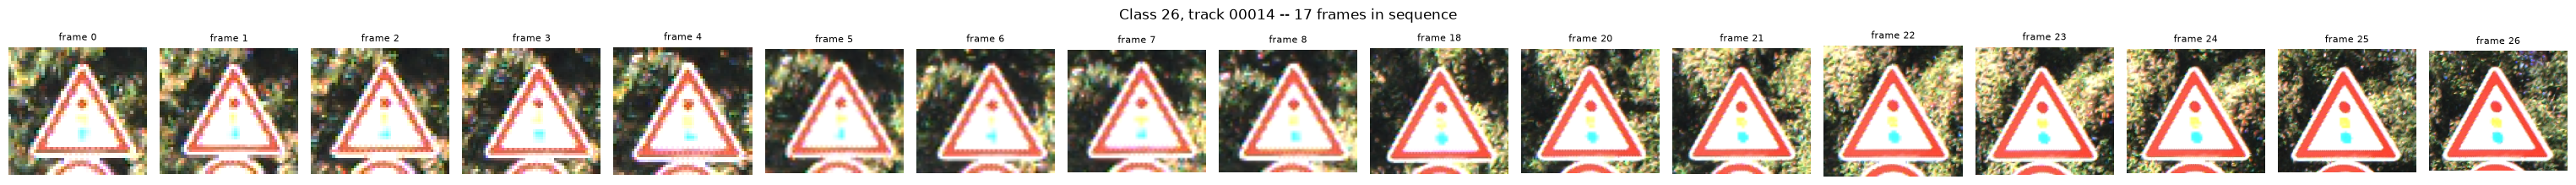

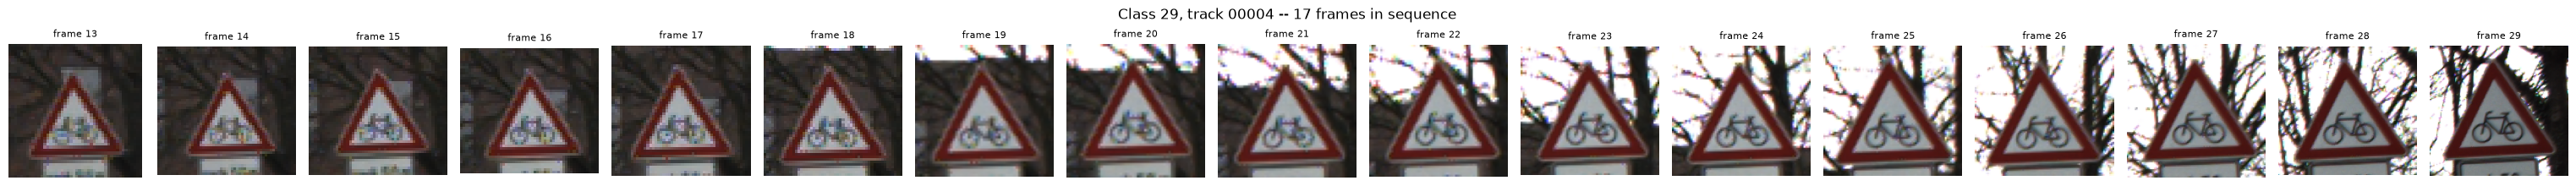

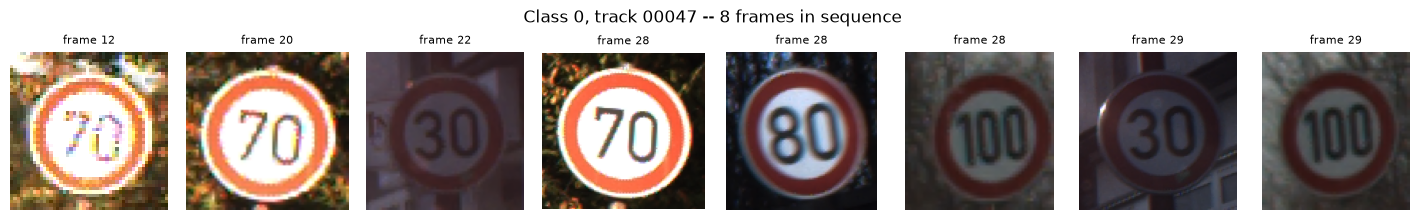

In [13]:
# Visually check a few pattern-A tracks with several frames: do they look
# like the same physical sign photographed moments apart?
candidate_groups = [k for k, v in track_sizes.items() if v >= 6]
random.seed(0)
example_groups = random.sample(candidate_groups, min(3, len(candidate_groups)))

for ex_class, ex_track in example_groups:
    frames = sorted(groups_a[(ex_class, ex_track)], key=lambda x: x[0])

    fig, axes = plt.subplots(1, len(frames), figsize=(len(frames) * 1.8, 2.2))
    if len(frames) == 1:
        axes = [axes]
    for ax, (frame_id, img_path) in zip(axes, frames):
        with Image.open(img_path) as img:
            ax.imshow(img.convert('RGB'))
        ax.set_title(f"frame {frame_id}", fontsize=8)
        ax.axis('off')
    plt.suptitle(f"Class {ex_class}, track {ex_track} — {len(frames)} frames in sequence")
    plt.tight_layout()
    plt.show()

### Result

Confirmed (numbers from the local audit; Colab should match exactly since
it's the same files): only ~10.3% of files cleanly match the
`prefix_track_frame` pattern (~6.6% are bare-numbered with no track info,
~0.2% match a third convention, and ~82.9% use other/unrecognized naming
— consistent with this dataset being merged from multiple original
sources, each with its own scheme).

For the files that *do* match the clean pattern: grouping by (class,
track) gives ~900 groups, averaging ~13 images each, with about 82% of
groups having 5 or more images — and the visual check above confirms
those really are near-duplicate frames of the same physical sign. That
confirms the leakage risk is real.

**But** filename parsing alone only reliably covers a fraction of the
dataset — it can't be used as the *only* method to build leakage-safe
splits in stage 4, since the majority of files don't have a cleanly
parseable track ID (even though many of their names — e.g. repeated stems
with incrementing suffixes — suggest they're likely grouped bursts too,
just in a different naming style). **Recommendation for stage 4.1**: use
content-based near-duplicate detection (e.g. perceptual image hashing) to
group visually-near-identical images across the *whole* dataset,
regardless of filename convention, rather than relying on filename
parsing alone.

Next: step 3.7, writing up the full stage-3 findings summary.